<a href="https://colab.research.google.com/github/uzmaa29/dnn-and-hyperparameter-optimizer/blob/main/DNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Deep Learning Task 1: Deep neural networks and hyperparameter optimization


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical #converts labels into one-hot encoding.

In [2]:
np.random.seed(42) #random weights.

In [3]:
(X_train, y_train), (X_test, y_test) = mnist.load_data() #why is preprocessig required here


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
print("Training data:", X_train.shape)
print("Test data:", X_test.shape)

Training data: (60000, 28, 28)
Test data: (10000, 28, 28)


In [5]:
X_train = X_train.astype("float32")/255.0
X_test = X_test.astype("float32")/255.0

In [6]:
X_train = X_train.reshape(X_train.shape[0], 784)
X_test = X_test.reshape(X_test.shape[0], 784)

In [7]:
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [8]:
print("Training data preprocessed:", X_train.shape)
print("Test data preprocessed:", X_test.shape)

Training data preprocessed: (60000, 784)
Test data preprocessed: (10000, 784)


In [9]:
plt.figure(figsize=(10,4))

<Figure size 1000x400 with 0 Axes>

<Figure size 1000x400 with 0 Axes>

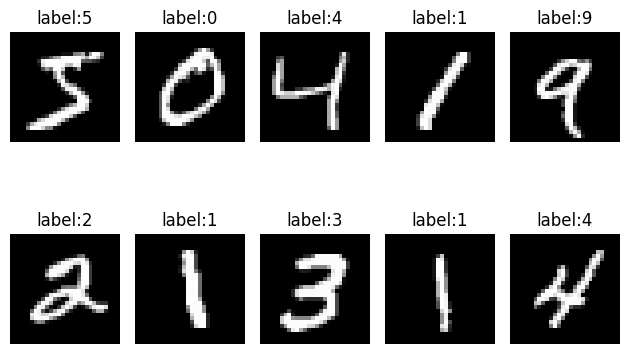

In [10]:
for i in range(10):
  plt.subplot(2, 5, i+1)
  plt.imshow(X_train[i].reshape(28, 28), cmap="gray")
  plt.title(f"label:{np.argmax(y_train[i])}")
  plt.axis("off")

plt.tight_layout()
plt.show()

In [11]:
#AF
def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -500, 500)))

def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)

def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float)

def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

In [12]:
#LF
def cross_entropy(y_true, y_pred):
    y_pred = np.clip(y_pred, 1e-10, 1 -1e-10)
    return -np.mean(np.sum(y_true * np.log(y_pred), axis =1))

In [13]:
# ============================================================
# 7. NEURAL NETWORK CLASS
# ============================================================

class NeuralNetwork:

    def __init__(
        self,
        input_size=784,
        hidden_size=128,
        output_size=10,
        learning_rate=0.001,
        activation="relu",
        optimizer="adam"
    ):

        self.learning_rate = learning_rate
        self.activation_name = activation
        self.optimizer_name = optimizer

        # Xavier-style initialization
        self.W1 = np.random.randn(input_size, hidden_size) * np.sqrt(2 / input_size)
        self.b1 = np.zeros((1, hidden_size))

        self.W2 = np.random.randn(hidden_size, output_size) * np.sqrt(2 / hidden_size)
        self.b2 = np.zeros((1, output_size))

        # Variables required for optimizers
        self.initialize_optimizer()


    # --------------------------------------------------------
    # ACTIVATION
    # --------------------------------------------------------

    def activation(self, x):

        if self.activation_name == "relu":
            return relu(x)

        elif self.activation_name == "sigmoid":
            return sigmoid(x)


    def activation_derivative(self, x):

        if self.activation_name == "relu":
            return relu_derivative(x)

        elif self.activation_name == "sigmoid":
            return sigmoid_derivative(x)


    # --------------------------------------------------------
    # INITIALIZE OPTIMIZER VARIABLES
    # --------------------------------------------------------

    def initialize_optimizer(self):

        # Momentum
        self.vW1 = np.zeros_like(self.W1)
        self.vb1 = np.zeros_like(self.b1)
        self.vW2 = np.zeros_like(self.W2)
        self.vb2 = np.zeros_like(self.b2)

        # RMSProp / Adam
        self.sW1 = np.zeros_like(self.W1)
        self.sb1 = np.zeros_like(self.b1)
        self.sW2 = np.zeros_like(self.W2)
        self.sb2 = np.zeros_like(self.b2)

        # Adam
        self.mW1 = np.zeros_like(self.W1)
        self.mb1 = np.zeros_like(self.b1)
        self.mW2 = np.zeros_like(self.W2)
        self.mb2 = np.zeros_like(self.b2)

        self.t = 0


    # --------------------------------------------------------
    # FORWARD PROPAGATION
    # --------------------------------------------------------

    def forward(self, X):

        self.Z1 = np.dot(X, self.W1) + self.b1
        self.A1 = self.activation(self.Z1)

        self.Z2 = np.dot(self.A1, self.W2) + self.b2
        self.A2 = softmax(self.Z2)

        return self.A2


    # --------------------------------------------------------
    # BACKPROPAGATION
    # --------------------------------------------------------

    def backward(self, X, y):

        m = X.shape[0]

        # Output layer error
        dZ2 = self.A2 - y

        dW2 = np.dot(self.A1.T, dZ2) / m
        db2 = np.sum(dZ2, axis=0, keepdims=True) / m

        # Hidden layer error
        dA1 = np.dot(dZ2, self.W2.T)
        dZ1 = dA1 * self.activation_derivative(self.Z1)

        dW1 = np.dot(X.T, dZ1) / m
        db1 = np.sum(dZ1, axis=0, keepdims=True) / m

        return dW1, db1, dW2, db2


    # --------------------------------------------------------
    # OPTIMIZER UPDATE
    # --------------------------------------------------------

    def update_weights(self, dW1, db1, dW2, db2):

        lr = self.learning_rate


        # ====================================================
        # SGD
        # ====================================================

        if self.optimizer_name == "sgd":

            self.W1 -= lr * dW1
            self.b1 -= lr * db1

            self.W2 -= lr * dW2
            self.b2 -= lr * db2


        # ====================================================
        # MOMENTUM
        # ====================================================

        elif self.optimizer_name == "momentum":

            beta = 0.9

            self.vW1 = beta * self.vW1 + lr * dW1
            self.vb1 = beta * self.vb1 + lr * db1

            self.vW2 = beta * self.vW2 + lr * dW2
            self.vb2 = beta * self.vb2 + lr * db2

            self.W1 -= self.vW1
            self.b1 -= self.vb1

            self.W2 -= self.vW2
            self.b2 -= self.vb2


        # ====================================================
        # RMSPROP
        # ====================================================

        elif self.optimizer_name == "rmsprop":

            beta = 0.9
            epsilon = 1e-8

            self.sW1 = beta * self.sW1 + (1 - beta) * dW1**2
            self.sb1 = beta * self.sb1 + (1 - beta) * db1**2

            self.sW2 = beta * self.sW2 + (1 - beta) * dW2**2
            self.sb2 = beta * self.sb2 + (1 - beta) * db2**2

            self.W1 -= lr * dW1 / (np.sqrt(self.sW1) + epsilon)
            self.b1 -= lr * db1 / (np.sqrt(self.sb1) + epsilon)

            self.W2 -= lr * dW2 / (np.sqrt(self.sW2) + epsilon)
            self.b2 -= lr * db2 / (np.sqrt(self.sb2) + epsilon)


        # ====================================================
        # ADAM
        # ====================================================

        elif self.optimizer_name == "adam":

            beta1 = 0.9
            beta2 = 0.999
            epsilon = 1e-8

            self.t += 1

            # First moment
            self.mW1 = beta1 * self.mW1 + (1 - beta1) * dW1
            self.mb1 = beta1 * self.mb1 + (1 - beta1) * db1

            self.mW2 = beta1 * self.mW2 + (1 - beta1) * dW2
            self.mb2 = beta1 * self.mb2 + (1 - beta1) * db2

            # Second moment
            self.sW1 = beta2 * self.sW1 + (1 - beta2) * dW1**2
            self.sb1 = beta2 * self.sb1 + (1 - beta2) * db1**2

            self.sW2 = beta2 * self.sW2 + (1 - beta2) * dW2**2
            self.sb2 = beta2 * self.sb2 + (1 - beta2) * db2**2

            # Bias correction
            mW1_corrected = self.mW1 / (1 - beta1**self.t)
            mb1_corrected = self.mb1 / (1 - beta1**self.t)

            mW2_corrected = self.mW2 / (1 - beta1**self.t)
            mb2_corrected = self.mb2 / (1 - beta1**self.t)

            sW1_corrected = self.sW1 / (1 - beta2**self.t)
            sb1_corrected = self.sb1 / (1 - beta2**self.t)

            sW2_corrected = self.sW2 / (1 - beta2**self.t)
            sb2_corrected = self.sb2 / (1 - beta2**self.t)

            # Update parameters
            self.W1 -= lr * mW1_corrected / (np.sqrt(sW1_corrected) + epsilon)
            self.b1 -= lr * mb1_corrected / (np.sqrt(sb1_corrected) + epsilon)

            self.W2 -= lr * mW2_corrected / (np.sqrt(sW2_corrected) + epsilon)
            self.b2 -= lr * mb2_corrected / (np.sqrt(sb2_corrected) + epsilon)


    # --------------------------------------------------------
    # PREDICTION
    # --------------------------------------------------------

    def predict(self, X):

        probabilities = self.forward(X)

        return np.argmax(probabilities, axis=1)


    # --------------------------------------------------------
    # ACCURACY
    # --------------------------------------------------------

    def accuracy(self, X, y):

        predictions = self.predict(X)
        actual = np.argmax(y, axis=1)

        return np.mean(predictions == actual)


    # --------------------------------------------------------
    # TRAINING
    # --------------------------------------------------------

    def train(
        self,
        X,
        y,
        epochs=10,
        batch_size=32,
        verbose=True
    ):

        history = {
            "loss": [],
            "accuracy": []
        }

        n_samples = X.shape[0]

        for epoch in range(epochs):

            # Shuffle data
            indices = np.random.permutation(n_samples)

            X_shuffled = X[indices]
            y_shuffled = y[indices]

            epoch_loss = 0
            batches = 0

            # Mini-batches
            for start in range(0, n_samples, batch_size):

                end = start + batch_size

                X_batch = X_shuffled[start:end]
                y_batch = y_shuffled[start:end]

                # Forward propagation
                predictions = self.forward(X_batch)

                # Calculate loss
                loss = cross_entropy(y_batch, predictions)

                # Backpropagation
                gradients = self.backward(X_batch, y_batch)

                # Update weights
                self.update_weights(*gradients)

                epoch_loss += loss
                batches += 1

            epoch_loss /= batches

            accuracy = self.accuracy(X, y)

            history["loss"].append(epoch_loss)
            history["accuracy"].append(accuracy)

            if verbose:
                print(
                    f"Epoch {epoch + 1}/{epochs} "
                    f"- Loss: {epoch_loss:.4f} "
                    f"- Accuracy: {accuracy:.4f}"
                )

        return history

single layer network training

In [14]:
class SingleLayerNN:

    def __init__(
        self,
        input_size=784,
        output_size=10,
        learning_rate=0.01,
        optimizer="sgd"
    ):

        self.learning_rate = learning_rate
        self.optimizer_name = optimizer

        self.W = np.random.randn(input_size, output_size) * 0.01
        self.b = np.zeros((1, output_size))

    def forward(self, X):

        self.Z = np.dot(X, self.W) + self.b

        return softmax(self.Z)

    def backward(self, X, y):

        m = X.shape[0]

        dZ = self.forward(X) - y

        dW = np.dot(X.T, dZ) / m
        db = np.sum(dZ, axis=0, keepdims=True) / m

        self.W -= self.learning_rate * dW
        self.b -= self.learning_rate * db

    def predict(self, X):

        probabilities = self.forward(X)

        return np.argmax(probabilities, axis=1)

    def accuracy(self, X, y):

        predictions = self.predict(X)
        actual = np.argmax(y, axis=1)

        return np.mean(predictions == actual)

    def train(self, X, y, epochs=10, batch_size=32):

        history = {
            "loss": [],
            "accuracy": []
        }

        n_samples = X.shape[0]

        for epoch in range(epochs):

            indices = np.random.permutation(n_samples)

            X_shuffled = X[indices]
            y_shuffled = y[indices]

            epoch_loss = 0
            batches = 0

            for start in range(0, n_samples, batch_size):

                end = start + batch_size

                X_batch = X_shuffled[start:end]
                y_batch = y_shuffled[start:end]

                predictions = self.forward(X_batch)

                loss = cross_entropy(y_batch, predictions)

                self.backward(X_batch, y_batch)

                epoch_loss += loss
                batches += 1

            epoch_loss /= batches

            accuracy = self.accuracy(X, y)

            history["loss"].append(epoch_loss)
            history["accuracy"].append(accuracy)

            print(
                f"Epoch {epoch + 1}/{epochs} "
                f"- Loss: {epoch_loss:.4f} "
                f"- Accuracy: {accuracy:.4f}"
            )

        return history

single layer model training

In [15]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

X_train_small = X_train[:20000]
y_train_small = y_train[:20000]

print("X_train_small:", X_train_small.shape)
print("y_train_small:", y_train_small.shape)

X_train: (60000, 784)
y_train: (60000, 10)
X_train_small: (20000, 784)
y_train_small: (20000, 10)


In [16]:
single_model = SingleLayerNN(
    input_size=784,
    output_size=10,
    learning_rate=0.1
)

single_history = single_model.train(
    X_train_small,
    y_train_small,
    epochs=5,
    batch_size=32
)

Epoch 1/5 - Loss: 0.5344 - Accuracy: 0.9001
Epoch 2/5 - Loss: 0.3538 - Accuracy: 0.9112
Epoch 3/5 - Loss: 0.3232 - Accuracy: 0.9161
Epoch 4/5 - Loss: 0.3068 - Accuracy: 0.9210
Epoch 5/5 - Loss: 0.2952 - Accuracy: 0.9238


In [17]:
## evaluation of singlelayer model

single_test_accuracy = single_model.accuracy(X_test, y_test)

print("Single-Layer Test Accuracy:",
      round(single_test_accuracy * 100, 2), "%")

Single-Layer Test Accuracy: 91.7 %


multi layer neural network traingin

In [18]:
model = NeuralNetwork(
    input_size=784,
    hidden_size=128,
    output_size=10,
    learning_rate=0.001,
    activation="relu",
    optimizer="adam"
)

history = model.train(
    X_train_small,
    y_train_small,
    epochs=10,
    batch_size=32
)

Epoch 1/10 - Loss: 0.3988 - Accuracy: 0.9447
Epoch 2/10 - Loss: 0.1807 - Accuracy: 0.9660
Epoch 3/10 - Loss: 0.1264 - Accuracy: 0.9768
Epoch 4/10 - Loss: 0.0934 - Accuracy: 0.9829
Epoch 5/10 - Loss: 0.0710 - Accuracy: 0.9870
Epoch 6/10 - Loss: 0.0537 - Accuracy: 0.9893
Epoch 7/10 - Loss: 0.0414 - Accuracy: 0.9917
Epoch 8/10 - Loss: 0.0326 - Accuracy: 0.9958
Epoch 9/10 - Loss: 0.0227 - Accuracy: 0.9972
Epoch 10/10 - Loss: 0.0197 - Accuracy: 0.9962


test accuracy


In [19]:
test_accuracy = model.accuracy(X_test, y_test)

print("Multi-layer test accruacy:")
print(round(test_accuracy * 100, 2), "%")

Multi-layer test accruacy:
96.56 %


training loss

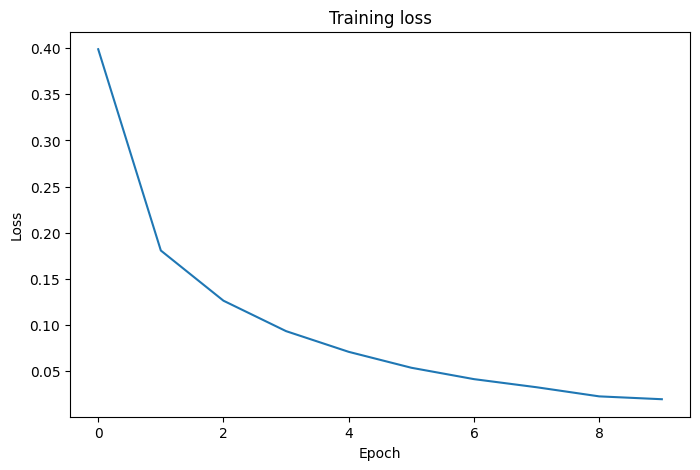

In [20]:
plt.figure(figsize=(8,5))

plt.plot(history["loss"])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training loss")
plt.show()

training accuracy

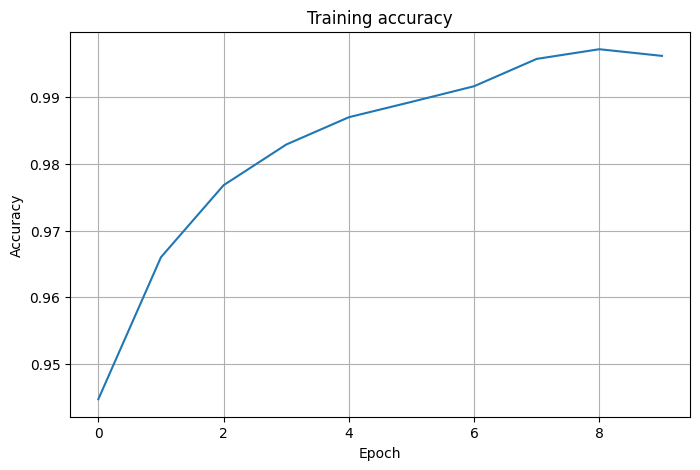

In [21]:
plt.figure(figsize=(8,5))

plt.plot(history["accuracy"])
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training accuracy")
plt.grid(True)
plt.show()

comparing optimisers

In [22]:
optimizers = [
    "sgd",
    "momentum",
    "rmsprop",
    "adam"
]

optimizer_results = {}

for optimizer in optimizers:

    print("Optimizer:", optimizer)


    model = NeuralNetwork(
        input_size=784,
        hidden_size=128,
        output_size=10,
        learning_rate=0.001,
        activation="relu",
        optimizer=optimizer
    )

    history_temp = model.train(
        X_train_small,
        y_train_small,
        epochs=5,
        batch_size=32,
        verbose=False
    )

    test_acc = model.accuracy(X_test, y_test)

    optimizer_results[optimizer] = {
        "accuracy": test_acc,
        "loss": history_temp["loss"][-1]
    }

    print("Final Loss:", history_temp["loss"][-1])
    print("Test Accuracy:", test_acc)

Optimizer: sgd
Final Loss: 0.8855334023482079
Test Accuracy: 0.829
Optimizer: momentum
Final Loss: 0.31520685289772393
Test Accuracy: 0.9137
Optimizer: rmsprop
Final Loss: 0.0807609063100623
Test Accuracy: 0.9606
Optimizer: adam
Final Loss: 0.07323062850283985
Test Accuracy: 0.9626


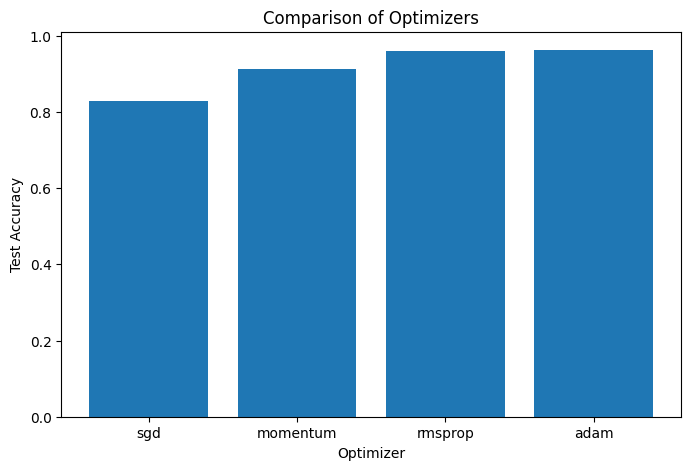

In [24]:
names = list(optimizer_results.keys())
accuracies = [
    optimizer_results[name]["accuracy"]
    for name in names
]

plt.figure(figsize=(8,5))
plt.bar(names, accuracies)
plt.xlabel("Optimizer")
plt.ylabel("Test Accuracy")
plt.title("Comparison of Optimizers")
plt.show()